In [1]:
# basics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# for NLP
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# optional: text pre-processing libraries (e.g., nltk or spaCy)
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Set plotting style
sns.set(style='whitegrid')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Replace with your actual CSV path
csv_path = 'xbox_manchester_uk_data.csv'

df = pd.read_csv(csv_path)

# Quick peek
df.head()

,user_id,region,city,age_group,gender,signup_date,sales_amount_gbp,cost_amount_gbp,profit_margin_pct,chat_text,sentiment_label
0,1001,UK,Manchester,25-34,Male,2025-08-12,120.5,80.0,33.6,"Loved the new game release, great experience!",
1,1002,UK,London,35-44,Female,2025-09-01,75.0,50.0,33.3,Had issues with connection during match,
2,1003,UK,Manchester,18-24,Other,2025-08-20,200.0,120.0,40.0,"Awesome weekend playing, really enjoyed it",
3,1004,UK,Birmingham,45-54,Male,2025-08-23,50.0,45.0,10.0,"Too many ads, not happy",


In [4]:
# check missing values
print(df.isnull().sum())

# fill or drop as appropriate
df = df.dropna(subset=['sales_amount_gbp', 'cost_amount_gbp', 'chat_text'])
# or, if needed:
# df['profit_margin_pct'] = df['profit_margin_pct'].fillna(
#     (df['sales_amount_gbp'] - df['cost_amount_gbp']) / df['sales_amount_gbp'] * 100
# )

# ensure correct data types
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['sales_amount_gbp'] = pd.to_numeric(df['sales_amount_gbp'], errors='coerce')
df['cost_amount_gbp'] = pd.to_numeric(df['cost_amount_gbp'], errors='coerce')

user_id              0
region               0
city                 0
age_group            0
gender               0
signup_date          0
sales_amount_gbp     0
cost_amount_gbp      0
profit_margin_pct    0
chat_text            0
sentiment_label      0
dtype: int64


In [5]:
# Add computed profit margin if not present
if 'profit_margin_pct' not in df.columns or df['profit_margin_pct'].isnull().any():
    df['profit_margin_pct'] = (
        (df['sales_amount_gbp'] - df['cost_amount_gbp']) / df['sales_amount_gbp'] * 100
    )

# Create time-based features
df['month'] = df['signup_date'].dt.month
df['year'] = df['signup_date'].dt.year

# One-hot encode categorical variables for regression
df_encoded = pd.get_dummies(df, columns=['region', 'city', 'age_group', 'gender'], drop_first=True)

# choose target: predict future sales_amount_gbp or profit_margin_pct
target = 'sales_amount_gbp'  # change to 'profit_margin_pct' if desired
features = df_encoded.drop(columns=[
    'user_id', 'signup_date', 'chat_text', 'sentiment_label',
    # if target is profit_margin_pct, keep sales and cost? depends on model design
])

In [6]:
X = features
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# predictions
y_pred = lr_model.predict(X_test)

# metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.3f}")

RMSE: 2.76
R^2: nan


/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [7]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_
}).sort_values(by='coefficient', ascending=False)

coef_df.head(15)  # top positive influences

,feature,coefficient
0,sales_amount_gbp,0.796167
1,cost_amount_gbp,0.401912
2,profit_margin_pct,0.013740
11,gender_Other,0.012506
9,age_group_45-54,0.002809
3,month,0.000000
4,year,0.000000
5,city_London,0.000000
8,age_group_35-44,0.000000
6,city_Manchester,-0.002809


In [8]:
# Define a simple preprocessor and tokenizer
def preprocess_text(text):
    if pd.isnull(text):
        return ""
    # lowercase
    text = text.lower()
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove numbers
    text = re.sub(r'\d+', '', text)
    # tokenization can be expanded
    return text

df['clean_text'] = df['chat_text'].apply(preprocess_text)

# If you don't already have sentiment labels, you could:
# - derive with a lexicon or heuristic
# - or leave unlabeled and run clustering / topic extraction

In [10]:
sent_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

In [15]:
print(df['sentiment_label'].unique())
print(df['sentiment_label'].value_counts())

[' ']
sentiment_label
    4
Name: count, dtype: int64


Columns in dataset:
user_id
region
city
age_group
gender
signup_date
sales_amount_gbp
cost_amount_gbp
profit_margin_pct
chat_text
sentiment_label
month
year
clean_text
Using sentiment column: sentiment_label


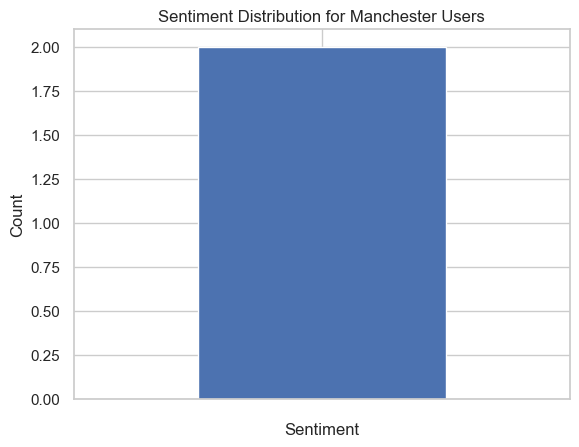

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Show available columns
print("Columns in dataset:")
for col in df.columns:
    print(col)

# Check city column
if 'city' not in df.columns:
    raise ValueError("Column 'city' not found in dataset")

# Automatically find sentiment column
sentiment_col = None
for col in df.columns:
    if 'sentiment' in col:
        sentiment_col = col
        break

if sentiment_col is None:
    raise ValueError("No sentiment column found in dataset")

print("Using sentiment column:", sentiment_col)

# Filter Manchester users
manchester_df = df[df['city'].str.lower() == 'manchester']

# Count sentiments
manchester_sent = manchester_df[sentiment_col].value_counts()

# Plot
manchester_sent.plot(kind='bar')

plt.title('Sentiment Distribution for Manchester Users')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()

In [21]:
# Group by city or age group, compute average sales, margin
demo_summary = df.groupby(['city', 'age_group']).agg(
    avg_sales=('sales_amount_gbp', 'mean'),
    avg_margin=('profit_margin_pct', 'mean'),
    total_sales=('sales_amount_gbp', 'sum'),
    count_users=('user_id', 'nunique')
).reset_index()

demo_summary.head(10)

,city,age_group,avg_sales,avg_margin,total_sales,count_users
0,Birmingham,45-54,50.0,10.0,50.0,1
1,London,35-44,75.0,33.3,75.0,1
2,Manchester,18-24,200.0,40.0,200.0,1
3,Manchester,25-34,120.5,33.6,120.5,1


In [22]:
manchester_demo = demo_summary[demo_summary['city'] == 'Manchester']
print(manchester_demo)

         city age_group  avg_sales  avg_margin  total_sales  count_users
2  Manchester     18-24      200.0        40.0        200.0            1
3  Manchester     25-34      120.5        33.6        120.5            1
